In [2]:
# Setup cell
!pip uninstall -y transformers tensorflow
!pip install tensorflow==2.17.0 transformers==4.40.0
!pip install -U ml_dtypes
# Add a print statement so you know it's done
print("Environment setup complete.")

Found existing installation: transformers 5.0.0
Uninstalling transformers-5.0.0:
  Successfully uninstalled transformers-5.0.0
Found existing installation: tensorflow 2.20.0
Uninstalling tensorflow-2.20.0:
  Successfully uninstalled tensorflow-2.20.0
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.6/137.6 kB 1.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 601.4/601.4 MB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.0/9.0 MB 41.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 19.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 54.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 36.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.2/295.2 kB 15.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 38.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 16.4 MB/s eta 0:00:00
  Attempting uninstall: ml_dtypes
    Found existing installation: ml-dtypes 0.4.1
    Uninstalling ml-dtypes-0.4.1:
      Successfully uninstalled ml-dtypes-0.4.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow 2.17.0 requires ml-dtypes<0.5.0,>=0.3.1, but you have ml-dtypes 0.5.4 which is incompatible.
ydf-tf 2.20.0 requires tensorflow==2.20.0, but you have tensorflow 2.17.0 which is incompatible.
tf-keras 2.20.0 requires tensorflow<2.21,>=2.20, but you have tensorflow 2.17.0 which is incompatible.
jaxlib 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
tensorflow-text 2.20.1 requires tensorflow<2.21,>=2.20.0, but you have tensorflow 2.17.0 which is incompatible.
jax 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
Envir

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# For TextCNN
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

# Evaluation
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print('TensorFlow version:', tf.__version__)

TensorFlow version: 2.17.0


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
TRAIN_DF = pd.read_csv('/content/drive/MyDrive/EmotionDataset/training.csv')
TEST_DF = pd.read_csv('/content/drive/MyDrive/EmotionDataset/test.csv')
VAL_DF = pd.read_csv('/content/drive/MyDrive/EmotionDataset/validation.csv')

print('Train size:', len(TRAIN_DF))
print('Validation size:', len(VAL_DF))
print('Test size:', len(TEST_DF))
print()
print('Columns:', TRAIN_DF.columns.tolist())
TRAIN_DF.head(10)

Train size: 16000
Validation size: 2000
Test size: 2000

Columns: ['text', 'label']


,text,label
0,i didnt feel humiliated,0
1,i can go from feeling so hopeless to so damned...,0
2,im grabbing a minute to post i feel greedy wrong,3
3,i am ever feeling nostalgic about the fireplac...,2
4,i am feeling grouchy,3
5,ive been feeling a little burdened lately wasn...,0
6,ive been taking or milligrams or times recomme...,5
7,i feel as confused about life as a teenager or...,4
8,i have been with petronas for years i feel tha...,1
9,i feel romantic too,2


In [4]:
# LABEL MAPPING
label_map = {
    0: 'sadness',
    1: 'joy',
    2: 'love',
    3: 'anger',
    4: 'fear',
    5: 'surprise'
}

TRAIN_DF['emotion'] = TRAIN_DF['label'].map(label_map)
TEST_DF['emotion'] = TEST_DF['label'].map(label_map)
VAL_DF['emotion'] = VAL_DF['label'].map(label_map)

print("Label Mapping: ", label_map)
print("\nClass distribution in training set: ")
print(TRAIN_DF['emotion'].value_counts())

Label Mapping:  {0: 'sadness', 1: 'joy', 2: 'love', 3: 'anger', 4: 'fear', 5: 'surprise'}

Class distribution in training set: 
emotion
joy         5362
sadness     4666
anger       2159
fear        1937
love        1304
surprise     572
Name: count, dtype: int64


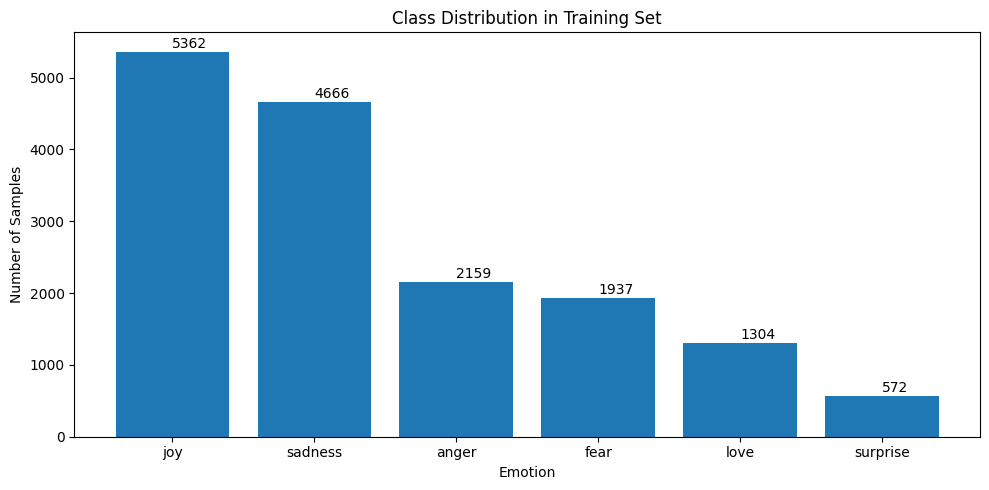

In [5]:
# Class distribution bar chart
plt.figure(figsize=(10, 5))

emotion_counts = TRAIN_DF['emotion'].value_counts()
plt.bar(emotion_counts.index, emotion_counts.values)
plt.title('Class Distribution in Training Set')
plt.xlabel("Emotion")
plt.ylabel("Number of Samples")
for i, v in enumerate(emotion_counts.values):
  plt.text(i, v + 50, str(v))


plt.tight_layout()
plt.show()

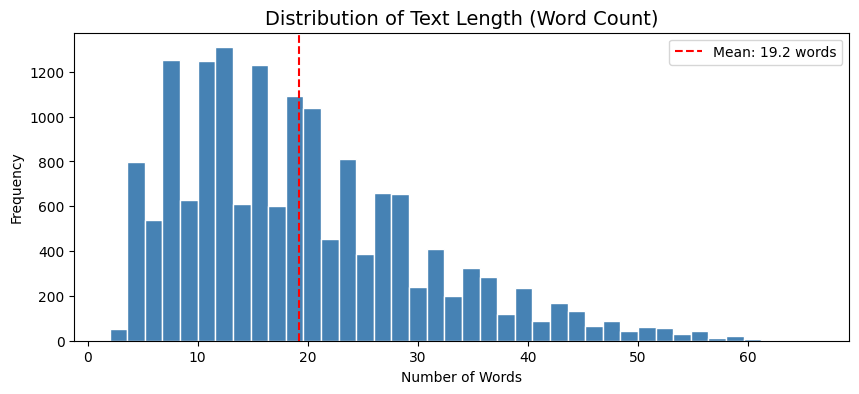

Average text length : 19.2 words
Max text length     : 66 words
Min text length     : 2 words


In [6]:
# Text length distribution

TRAIN_DF['text_length'] = TRAIN_DF['text'].apply(lambda x: len(x.split()))

plt.figure(figsize=(10, 4))
plt.hist(TRAIN_DF['text_length'], bins=40, color='steelblue', edgecolor='white')
plt.title('Distribution of Text Length (Word Count)', fontsize=14)
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.axvline(TRAIN_DF['text_length'].mean(), color='red', linestyle='--',
            label=f"Mean: {TRAIN_DF['text_length'].mean():.1f} words")
plt.legend()
plt.show()

print(f"Average text length : {TRAIN_DF['text_length'].mean():.1f} words")
print(f"Max text length     : {TRAIN_DF['text_length'].max()} words")
print(f"Min text length     : {TRAIN_DF['text_length'].min()} words")

In [7]:
# Sample data examples
for emotion in label_map.values():
    sample = TRAIN_DF[TRAIN_DF['emotion'] == emotion]['text'].values[0]
    print(f'\n[{emotion.upper()}] {sample}')


[SADNESS] i didnt feel humiliated

[JOY] i have been with petronas for years i feel that petronas has performed well and made a huge profit

[LOVE] i am ever feeling nostalgic about the fireplace i will know that it is still on the property

[ANGER] im grabbing a minute to post i feel greedy wrong

[FEAR] i feel as confused about life as a teenager or as jaded as a year old man

[SURPRISE] ive been taking or milligrams or times recommended amount and ive fallen asleep a lot faster but i also feel like so funny


In [28]:
# Preprocessing

MAX_WORDS = 10000 # vocabulary size
MAX_LEN = 50 # max words per sentence
EMBED_DIM = 64 # embedding vector size
EMBED_DIM2 = 128 # embedding vector size
NUM_CLASSES = len(label_map)

# Tokenizer = converts words -> integers
tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token='<OOV')
tokenizer.fit_on_texts(TRAIN_DF['text']) # learn vocab from training data

# convert text -> sequences of integers
x_train_seq = tokenizer.texts_to_sequences(TRAIN_DF['text'])
x_test_seq = tokenizer.texts_to_sequences(TEST_DF['text'])
x_val_seq = tokenizer.texts_to_sequences(VAL_DF['text'])

# pad sequences to same length
x_train_pad = pad_sequences(x_train_seq, maxlen=MAX_LEN, padding='post', truncating='post')
x_test_pad = pad_sequences(x_test_seq, maxlen=MAX_LEN, padding='post', truncating='post')
x_val_pad = pad_sequences(x_val_seq, maxlen=MAX_LEN, padding='post', truncating='post')

# labels
y_train = TRAIN_DF['label'].values
y_test = TEST_DF['label'].values
y_val = VAL_DF['label'].values

print('Example padded sequence: ', x_train_pad[0])
print('Vocabulary size: ', len(tokenizer.word_index))

Example padded sequence:  [  2 139   3 679   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
Vocabulary size:  15213


CNN

In [29]:
def build_textcnn(vocab_size, embed_dim, max_len, num_classes):
  inputs = layers.Input(shape=(max_len,))

  x = layers.Embedding(vocab_size, embed_dim)(inputs)

  conv2 = layers.Conv1D(128, kernel_size=2, activation='relu')(x)
  conv3 = layers.Conv1D(128, kernel_size=3, activation='relu')(x)

  pool2 = layers.GlobalMaxPooling1D()(conv2)
  pool3 = layers.GlobalMaxPooling1D()(conv3)

  merged = layers.Concatenate()([pool2, pool3])

  dropped = layers.Dropout(0.5)(merged)

  outputs = layers.Dense(num_classes, activation='softmax')(dropped)

  model = Model(inputs, outputs)
  return model


cnn_model = build_textcnn(
    vocab_size = MAX_WORDS,
    embed_dim = EMBED_DIM,
    max_len = MAX_LEN,
    num_classes = NUM_CLASSES
)

cnn_model.compile(
    optimizer = 'adam',
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy']
)

CNNcheckpoint = ModelCheckpoint(
    filepath='/content/drive/MyDrive/best_cnn_model.keras',
    monitor='val_loss',
    save_best_only=True,
    mode='min',
    verbose=1
)

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

cnn_model.summary()

Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_6       │ (None, 50)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_6         │ (None, 50, 64)    │    640,000 │ input_layer_6[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_23 (Conv1D)  │ (None, 49, 128)   │     16,512 │ embedding_6[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_24 (Conv1D)  │ (None, 48, 128)   │     24,704 │ embedding_6[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 128)       │          0 │ conv1d_23[0][0]   │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 128)       │          0 │ conv1d_24[0][0]   │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_6       │ (None, 256)       │          0 │ global_max_pooli… │
│ (Concatenate)       │                   │            │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_10          │ (None, 256)       │          0 │ concatenate_6[0]… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_10 (Dense)    │ (None, 6)         │      1,542 │ dropout_10[0][0]  │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 682,758 (2.60 MB)

 Trainable params: 682,758 (2.60 MB)

 Non-trainable params: 0 (0.00 B)

In [30]:
# Train CNN
cnn_history = cnn_model.fit(
    x_train_pad, y_train, validation_data = (x_val_pad, y_val),
    epochs = 20,
    batch_size = 64,
    verbose = 1,
    callbacks=[CNNcheckpoint, early_stopping]
)

Epoch 1/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.3759 - loss: 1.5482
Epoch 1: val_loss improved from None to 0.39968, saving model to /content/drive/MyDrive/best_cnn_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/best_cnn_model.keras
250/250 ━━━━━━━━━━━━━━━━━━━━ 12s 42ms/step - accuracy: 0.5222 - loss: 1.2735 - val_accuracy: 0.8770 - val_loss: 0.3997
Epoch 2/20
249/250 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.9040 - loss: 0.2846
Epoch 2: val_loss improved from 0.39968 to 0.17374, saving model to /content/drive/MyDrive/best_cnn_model.keras

Epoch 2: finished saving model to /content/drive/MyDrive/best_cnn_model.keras
250/250 ━━━━━━━━━━━━━━━━━━━━ 8s 30ms/step - accuracy: 0.9125 - loss: 0.2343 - val_accuracy: 0.9215 - val_loss: 0.1737
Epoch 3/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 0.9351 - loss: 0.1595
Epoch 3: val_loss improved from 0.17374 to 0.16817, saving model to /content/drive/MyDrive/best_cnn_model.keras

Epoch 3: f

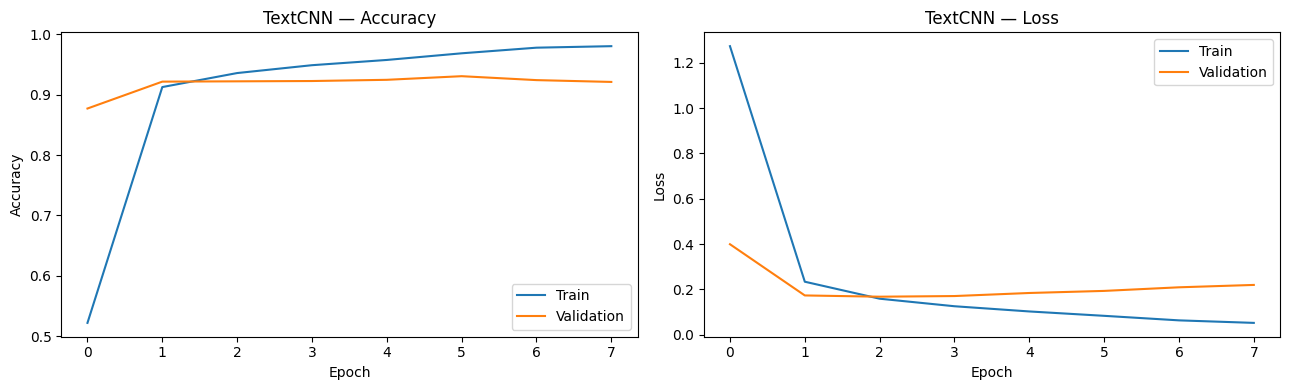

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(cnn_history.history['accuracy'],     label='Train')
axes[0].plot(cnn_history.history['val_accuracy'], label='Validation')
axes[0].set_title('TextCNN — Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(cnn_history.history['loss'],     label='Train')
axes[1].plot(cnn_history.history['val_loss'], label='Validation')
axes[1].set_title('TextCNN — Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()

Fine-Tuned CNN

In [36]:
def build_textcnn2(vocab_size, embed_dim, max_len, num_classes):
  inputs = layers.Input(shape=(max_len,))

  x = layers.Embedding(vocab_size, embed_dim)(inputs)

  conv2 = layers.Conv1D(256, kernel_size=2, activation='relu')(x)
  conv3 = layers.Conv1D(256, kernel_size=3, activation='relu')(x)
  conv4 = layers.Conv1D(256, kernel_size=4, activation='relu')(x)

  pool2 = layers.GlobalMaxPooling1D()(conv2)
  pool3 = layers.GlobalMaxPooling1D()(conv3)
  pool4 = layers.GlobalMaxPooling1D()(conv4)

  merged = layers.Concatenate()([pool2, pool3, pool4])

  dropped = layers.Dropout(0.3)(merged)

  outputs = layers.Dense(num_classes, activation='softmax')(dropped)

  model = Model(inputs, outputs)
  return model


cnn_model2 = build_textcnn2(
    vocab_size = MAX_WORDS,
    embed_dim = EMBED_DIM2,
    max_len = MAX_LEN,
    num_classes = NUM_CLASSES
)

cnn_model2.compile(
    optimizer = 'adam',
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy']
)

CNN2checkpoint = ModelCheckpoint(
    filepath='/content/drive/MyDrive/best_cnn2_model.keras',
    monitor='val_loss',
    save_best_only=True,
    mode='min',
    verbose=1
)

early_stopping2 = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

cnn_model2.summary()

Model: "functional_8"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_8       │ (None, 50)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_8         │ (None, 50, 128)   │  1,280,000 │ input_layer_8[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_28 (Conv1D)  │ (None, 49, 256)   │     65,792 │ embedding_8[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_29 (Conv1D)  │ (None, 48, 256)   │     98,560 │ embedding_8[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_30 (Conv1D)  │ (None, 47, 256)   │    131,328 │ embedding_8[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 256)       │          0 │ conv1d_28[0][0]   │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 256)       │          0 │ conv1d_29[0][0]   │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 256)       │          0 │ conv1d_30[0][0]   │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_8       │ (None, 768)       │          0 │ global_max_pooli… │
│ (Concatenate)       │                   │            │ global_max_pooli… │
│                     │                   │            │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_12          │ (None, 768)       │          0 │ concatenate_8[0]… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_12 (Dense)    │ (None, 6)         │      4,614 │ dropout_12[0][0]  │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,580,294 (6.03 MB)

 Trainable params: 1,580,294 (6.03 MB)

 Non-trainable params: 0 (0.00 B)

In [37]:
# Train CNN2
cnn_history2 = cnn_model2.fit(
    x_train_pad, y_train, validation_data = (x_val_pad, y_val),
    epochs = 20,
    batch_size = 64,
    verbose = 1,
    callbacks=[CNN2checkpoint, early_stopping2]
)

Epoch 1/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step - accuracy: 0.4760 - loss: 1.3505
Epoch 1: val_loss improved from None to 0.17844, saving model to /content/drive/MyDrive/best_cnn2_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/best_cnn2_model.keras
250/250 ━━━━━━━━━━━━━━━━━━━━ 48s 184ms/step - accuracy: 0.6751 - loss: 0.8792 - val_accuracy: 0.9260 - val_loss: 0.1784
Epoch 2/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step - accuracy: 0.9331 - loss: 0.1505
Epoch 2: val_loss improved from 0.17844 to 0.17135, saving model to /content/drive/MyDrive/best_cnn2_model.keras

Epoch 2: finished saving model to /content/drive/MyDrive/best_cnn2_model.keras
250/250 ━━━━━━━━━━━━━━━━━━━━ 44s 175ms/step - accuracy: 0.9310 - loss: 0.1552 - val_accuracy: 0.9250 - val_loss: 0.1713
Epoch 3/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step - accuracy: 0.9528 - loss: 0.1056
Epoch 3: val_loss improved from 0.17135 to 0.17132, saving model to /content/drive/MyDrive/best_cnn2_model.keras


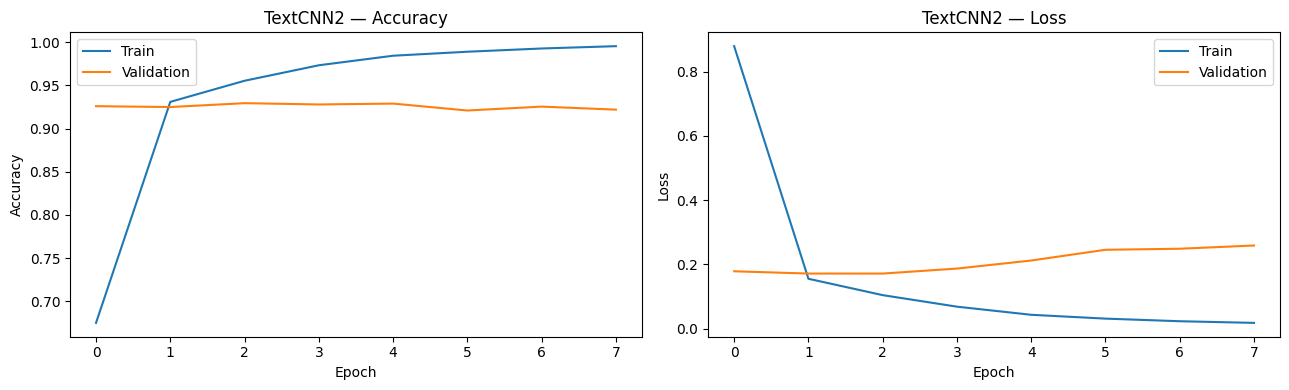

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(cnn_history2.history['accuracy'],     label='Train')
axes[0].plot(cnn_history2.history['val_accuracy'], label='Validation')
axes[0].set_title('TextCNN2 — Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(cnn_history2.history['loss'],     label='Train')
axes[1].plot(cnn_history2.history['val_loss'], label='Validation')
axes[1].set_title('TextCNN2 — Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()

In [39]:
cnn_model.load_weights('/content/drive/MyDrive/best_cnn_model.keras')
cnn_model2.load_weights('/content/drive/MyDrive/best_cnn2_model.keras')

# textCNN predictions
cnn_prob = cnn_model.predict(x_test_pad, verbose=0)
cnn_pred = np.argmax(cnn_prob, axis=1)
cnn_acc  = accuracy_score(y_test, cnn_pred)

# textCNN2 predictions
cnn2_prob = cnn_model2.predict(x_test_pad, verbose=0)
cnn2_pred = np.argmax(cnn2_prob, axis=1)
cnn2_acc  = accuracy_score(y_test, cnn2_pred)

print(f'TextCNN  Test Accuracy: {cnn_acc:.4f} ({cnn_acc*100:.2f}%)')
print(f'TextCNN2 Test Accuracy: {cnn2_acc:.4f} ({cnn2_acc*100:.2f}%)')

TextCNN  Test Accuracy: 0.9235 (92.35%)
TextCNN2 Test Accuracy: 0.9240 (92.40%)


In [40]:
emotion_names = list(label_map.values())

print('=' * 55)
print('         TEXTCNN — Classification Report')
print('=' * 55)
print(classification_report(y_test, cnn_pred, target_names=emotion_names))

print('=' * 55)
print('         TEXTCNN2 — Classification Report')
print('=' * 55)
print(classification_report(y_test, cnn2_pred, target_names=emotion_names))

         TEXTCNN — Classification Report
              precision    recall  f1-score   support

     sadness       0.95      0.97      0.96       581
         joy       0.92      0.97      0.94       695
        love       0.85      0.73      0.79       159
       anger       0.94      0.91      0.92       275
        fear       0.90      0.90      0.90       224
    surprise       0.82      0.64      0.72        66

    accuracy                           0.92      2000
   macro avg       0.90      0.85      0.87      2000
weighted avg       0.92      0.92      0.92      2000

         TEXTCNN2 — Classification Report
              precision    recall  f1-score   support

     sadness       0.96      0.97      0.96       581
         joy       0.92      0.96      0.94       695
        love       0.83      0.76      0.80       159
       anger       0.94      0.90      0.92       275
        fear       0.87      0.95      0.91       224
    surprise       0.90      0.56      0.69      

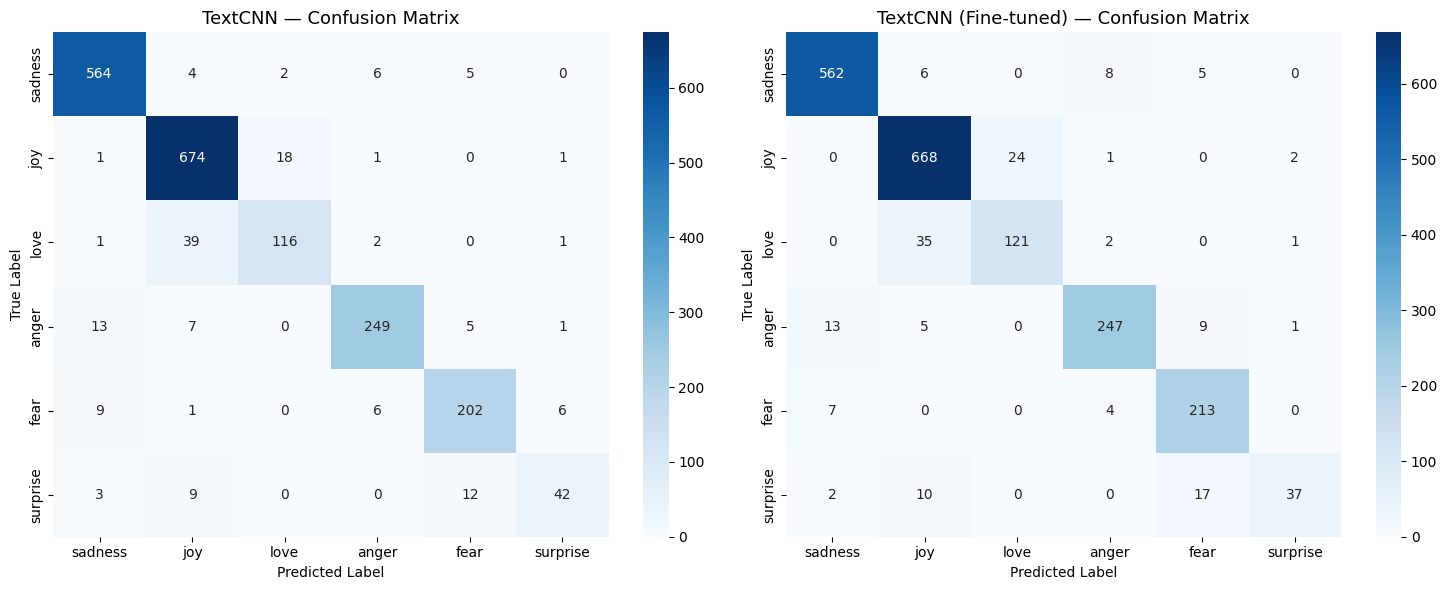

In [41]:
# Confusion Matrices
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for ax, preds, title in zip(
    axes,
    [cnn_pred, cnn2_pred],
    ['TextCNN', 'TextCNN (Fine-tuned)']
):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=emotion_names,
        yticklabels=emotion_names,
        ax=ax
    )
    ax.set_title(f'{title} — Confusion Matrix', fontsize=13)
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')

plt.tight_layout()
plt.show()

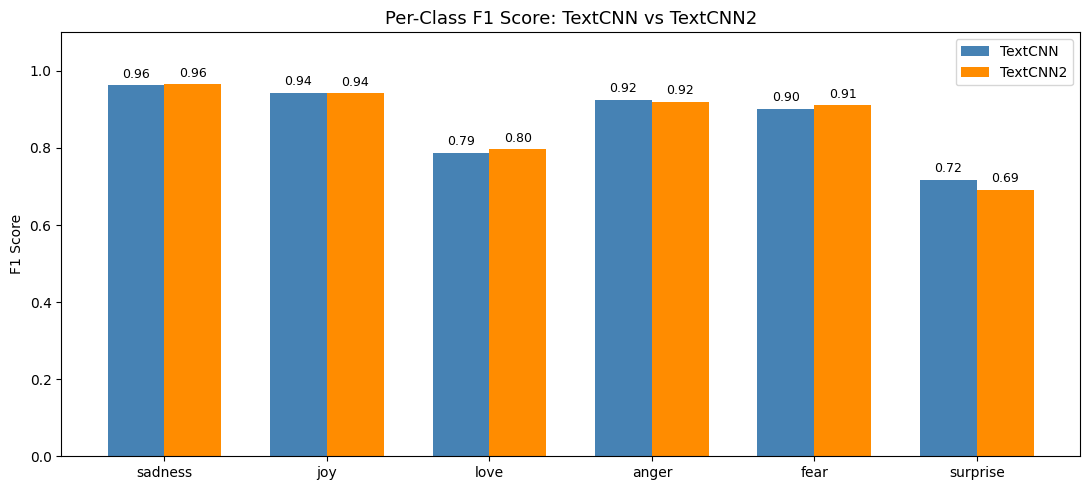

In [43]:
# Per-Class F1 Score Comparison
from sklearn.metrics import f1_score

cnn_f1s  = f1_score(y_test, cnn_pred,  average=None)
cnn2_f1s = f1_score(y_test, cnn2_pred, average=None)

x     = np.arange(len(emotion_names))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 5))
bars1 = ax.bar(x - width/2, cnn_f1s,  width, label='TextCNN', color='steelblue')
bars2 = ax.bar(x + width/2, cnn2_f1s, width, label='TextCNN2', color='darkorange')

ax.set_xticks(x)
ax.set_xticklabels(emotion_names)
ax.set_ylabel('F1 Score')
ax.set_title('Per-Class F1 Score: TextCNN vs TextCNN2', fontsize=13)
ax.set_ylim(0, 1.1)
ax.legend()

# Add value labels on bars
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, f'{bar.get_height():.2f}', ha='center', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, f'{bar.get_height():.2f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

In [45]:
from sklearn.metrics import f1_score

# summary metrics
cnn_f1_weighted  = f1_score(y_test, cnn_pred,  average='weighted')
cnn2_f1_weighted = f1_score(y_test, cnn2_pred, average='weighted')

cnn_f1_macro  = f1_score(y_test, cnn_pred,  average='macro')
cnn2_f1_macro = f1_score(y_test, cnn2_pred, average='macro')

comparison_df = pd.DataFrame({
    'Metric'         : ['Test Accuracy', 'Weighted F1', 'Macro F1', 'Trainable Params', 'Training Epochs'],
    'TextCNN'        : [f'{cnn_acc:.4f}', f'{cnn_f1_weighted:.4f}', f'{cnn_f1_macro:.4f}', f'{cnn_model.count_params():,}', '10'],
    'TextCNN (Fine-tuned)': [f'{cnn2_acc:.4f}', f'{cnn2_f1_weighted:.4f}', f'{cnn2_f1_macro:.4f}', f'{cnn_model2.count_params():,}', '3']
})

print('=' * 60)
print('         MODEL COMPARISON SUMMARY')
print('=' * 60)
print(comparison_df.to_string(index=False))
print('=' * 60)

         MODEL COMPARISON SUMMARY
          Metric TextCNN TextCNN (Fine-tuned)
   Test Accuracy  0.9235               0.9240
     Weighted F1  0.9217               0.9220
        Macro F1  0.8726               0.8707
Trainable Params 682,758            1,580,294
 Training Epochs      10                    3


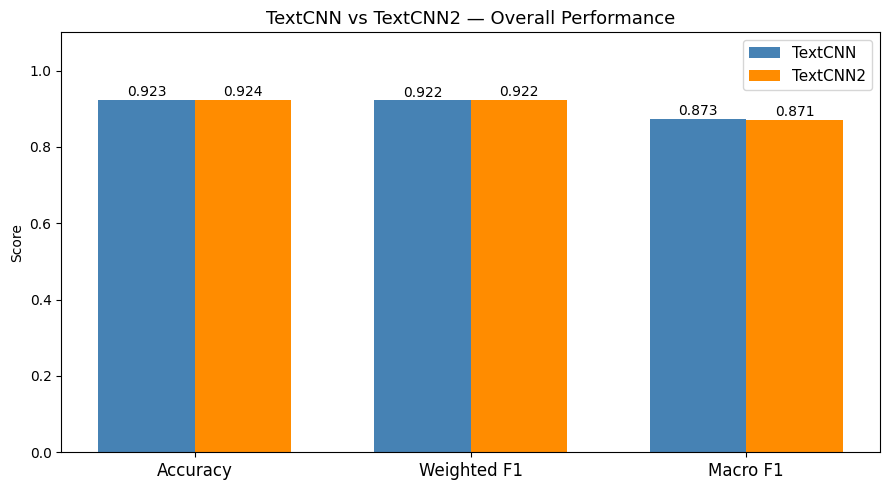

In [46]:
# Accuracy Comparison Bar Chart
metrics      = ['Accuracy', 'Weighted F1', 'Macro F1']
cnn_scores   = [cnn_acc, cnn_f1_weighted, cnn_f1_macro]
cnn2_scores   = [cnn2_acc, cnn2_f1_weighted, cnn2_f1_macro]

x     = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar(x - width/2, cnn_scores,  width, label='TextCNN', color='steelblue')
bars2 = ax.bar(x + width/2, cnn2_scores, width, label='TextCNN2',    color='darkorange')

ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=12)
ax.set_ylabel('Score')
ax.set_title('TextCNN vs TextCNN2 — Overall Performance', fontsize=13)
ax.set_ylim(0, 1.1)
ax.legend(fontsize=11)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', fontsize=10)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()